# TDA-Based Event Detection Using Moving Windows

This notebook implements a trajectory-based event detection workflow using topological data analysis (TDA). The example uses the synthetic three-tank system (TTS) dataset generated in the accompanying data-generation tutorial.

The central idea is to represent multivariate time-series data as a sequence of moving-window manifolds, compute topological descriptors for each window, and then analyze how those descriptors evolve over time.

For the $k$-th moving window, the local data matrix is represented as:

$$
\mathbf{X}_k \in \mathbb{R}^{M_k \times n}
$$

where $M_k$ is the number of time samples in the window and $n$ is the number of measured process variables.

In the TDA workflow, each window is converted into a 2D scalar field, and the Euler characteristic (EC) curve is computed using cubical-complex filtrations. The resulting sequence of EC curves is then used as a trajectory-based representation of the process.

For this synthetic three-variable example, a dense neural network is used to learn the temporal derivative of the EC curves. In the manuscript, this step is formulated using a neural ordinary differential equation (NODE). However, because this synthetic dataset has only three measured variables, the EC curves can be highly piecewise constant and may not provide sufficiently smooth descriptor trajectories for stable NODE learning. For smoother TDA descriptor trajectories, such as those obtained from higher-dimensional multivariate process data, the NODE formulation can be used directly.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gudhi as gd

from pathlib import Path
from tqdm import tqdm
from tensorflow.keras import layers, models

## Load the Synthetic Three-Tank System Dataset

The dataset contains the measured liquid-level signals $h_1(t)$, $h_2(t)$, and $h_3(t)$, together with true states, inputs, flows, and fault labels. For TDA-based event detection, we use only the measured liquid-level variables as the multivariate monitoring data:

$$
\mathbf{x}(t) =
\begin{bmatrix}
h_1(t) & h_2(t) & h_3(t)
\end{bmatrix}^{T}
$$

The code below loads `TTS_multifault_short_events.csv`. Update `csv_path` if the dataset is stored in a different directory.

In [2]:
# Load data

csv_path = Path("../Example_Dataset/TTS_multifault_short_events.csv")

# If the CSV is in the same folder as this notebook, use:
# csv_path = Path("TTS_multifault_short_events.csv")

df = pd.read_csv(csv_path)

print(f"Loaded: {csv_path}")
print(df.head())

Loaded: TTS_multifault_short_events.csv
     t    q1_cmd    q3_cmd   h1_true   h2_true   h3_true   h1_meas   h2_meas  \
0  0.0  0.000022  0.000014  0.120000  0.100000  0.080000  0.119505  0.100718   
1  1.0  0.000022  0.000014  0.118991  0.099900  0.077705  0.118807  0.100908   
2  2.0  0.000022  0.000014  0.118033  0.099630  0.075610  0.118677  0.098973   
3  3.0  0.000022  0.000014  0.117114  0.099226  0.073687  0.117211  0.099146   
4  4.0  0.000022  0.000014  0.116224  0.098715  0.071911  0.116684  0.098793   

    h3_meas  q12_true  q23_true   q2_true  fault_active fault_type  fault_id  
0  0.080067  0.000038  0.000038  0.000088             0     normal        -1  
1  0.077018  0.000037  0.000040  0.000086             0     normal        -1  
2  0.075740  0.000036  0.000041  0.000085             0     normal        -1  
3  0.072973  0.000036  0.000042  0.000084             0     normal        -1  
4  0.072570  0.000035  0.000044  0.000083             0     normal        -1  


## Select Measured Variables and Normalize

We use the noisy measured variables as the monitoring signals:

$$
\mathbf{X} =
\begin{bmatrix}
\mathbf{x}(t_1)^T \\
\mathbf{x}(t_2)^T \\
\vdots \\
\mathbf{x}(t_M)^T
\end{bmatrix}
\in \mathbb{R}^{M \times n}
$$

where $M$ is the number of time samples and $n=3$ for this synthetic TTS example.

Each variable is normalized to $[0,1]$ so that the reconstruction error is not dominated by differences in variable scale.

In [3]:
# Variable Normalization

time_col = "t"
meas_cols = ["h1_meas", "h2_meas", "h3_meas"]

t = df[time_col].to_numpy(dtype=float)
X_raw = df[meas_cols].copy()

# Linear interpolation fills short NaN gaps; bfill/ffill handle edge cases
X_raw = X_raw.interpolate(method="linear", limit_direction="both")
X_raw = X_raw.bfill().ffill()

X = X_raw.to_numpy(dtype=float)

# Min-max normalization for each measured variable.
x_min = X.min(axis=0, keepdims=True)
x_max = X.max(axis=0, keepdims=True)
data_norm = (X - x_min) / (x_max - x_min + 1e-12)

print("Normalized data shape:", data_norm.shape)

Normalized data shape: (4001, 3)


## Construct the Manifold Representation

The normalized time-series matrix has shape $M \times n$, where rows correspond to time samples and columns correspond to measured variables.

For the TDA workflow, we transpose this matrix to obtain:

$$
\mathbf{Y} = \mathcal{N}(\mathbf{X}^{T}) \in [0,1]^{n \times M}
$$

In this representation, rows correspond to process variables, columns correspond to time samples, and the matrix intensity denotes the normalized measured value.

Each moving window restricts this manifold representation to a local time interval.

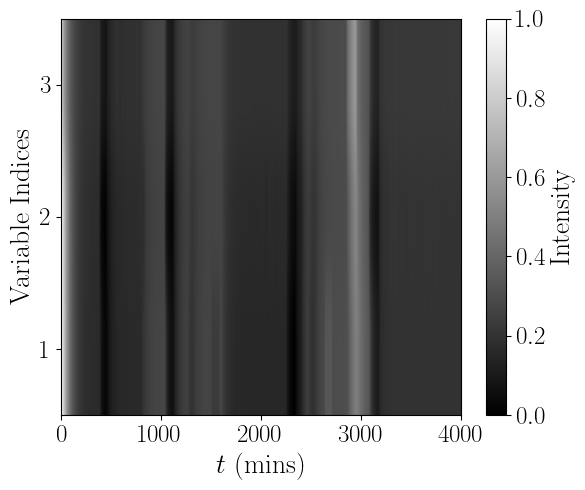

In [4]:
# 2D Manifold representation
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'axes.labelsize': 20,  
    'xtick.labelsize': 18, 
    'ytick.labelsize': 18, 
    'axes.titlesize': 24 
})

image_data = data_norm.T

plt.figure(figsize=(6,5))
plt.imshow(image_data, cmap='gray', aspect='auto')
plt.gca().invert_yaxis()
plt.ylabel('Variable Indices')
plt.xlabel('$t$ (mins)')
plt.yticks([0, 1, 2], [1, 2, 3])
cbar = plt.colorbar()
cbar.set_label("Intensity", fontsize=20)
plt.tight_layout()
plt.show()

## Define the Cubical-Complex EC Calculation

For each moving window, the local manifold is interpreted as a scalar field:

$$
h_k(i,j) = (\mathbf{Y}_k)_{i,j}
$$

A sublevel-set filtration is constructed over thresholds $\ell \in [0,1]$:

$$
\mathcal{S}_k(\ell)
=
\{(i,j): h_k(i,j) \leq \ell\}
$$

For each filtration threshold, the Betti numbers $\beta_0^{(k)}(\ell)$ and $\beta_1^{(k)}(\ell)$ are computed. The Euler characteristic is then:

$$
\chi_k(\ell)
=
\beta_0^{(k)}(\ell)
-
\beta_1^{(k)}(\ell)
$$

The EC curve $\chi_k(\ell)$ provides a compact topological descriptor of the $k$-th moving window.

In [5]:
# Cubical-complex EC and Betti calculation

def getECBetti_Cubical_fil(data, filtrations):
    """
    Compute Euler characteristic and Betti curves for a 2D data matrix
    using a cubical complex.

    Parameters
    ----------
    data : np.ndarray
        2D windowed manifold data with shape (n_variables, window_size).
    filtrations : np.ndarray
        Filtration thresholds.

    Returns
    -------
    EC : np.ndarray
        Euler characteristic curve.
    betti0s : np.ndarray
        Betti-0 curve.
    betti1s : np.ndarray
        Betti-1 curve.
    """

    cubeplex = gd.CubicalComplex(
        dimensions=[data.shape[1], data.shape[0]],
        top_dimensional_cells=np.ndarray.flatten(data)
    )

    cubeplex.compute_persistence()

    b = np.zeros((len(filtrations), 2))
    ec = np.zeros(len(filtrations))

    for i, fval in enumerate(filtrations):
        betti = cubeplex.persistent_betti_numbers(fval, fval)

        beta0 = betti[0] if len(betti) > 0 else 0
        beta1 = betti[1] if len(betti) > 1 else 0

        b[i] = [beta0, beta1]
        ec[i] = beta0 - beta1

    EC = ec
    betti0s = b[:, 0]
    betti1s = b[:, 1]

    return EC, betti0s, betti1s

## Compute EC Curves Over Moving Windows

The TDA descriptors are computed on a moving-window basis. Each window is represented as:

$$
W_k = [\tau_k^s, \tau_k^e], \qquad k=1,\dots,K
$$

For this synthetic example, we use:

- window size = 60 samples,
- overlap = 10%,
- 201 filtration thresholds over $[0,1]$.

The representative time of each window is taken as the start time:

$$
\tau_k = \tau_k^s
$$

The output of this step is a sequence of EC curves:

$$
\{\chi_k(\ell)\}_{k=1}^{K}
$$

In [6]:
# Moving-window TDA descriptor extraction

num_filtrations = 201
filtrations = np.linspace(0.0, 1.0, num_filtrations)

window_width = 60
overlap_percentage = 10
step = int(window_width * (1.0 - overlap_percentage / 100.0))

if step < 1:
    raise ValueError("Step size must be at least 1. Reduce overlap or increase window width.")

window_length = image_data.shape[0]
time_size = image_data.shape[1]

window_data = []
window_ec = []
window_betti0 = []
window_betti1 = []
window_start_idx = []

for i in (range(0, time_size - window_width + 1, step)):
    data_window = image_data[0:window_length, i:i + window_width]

    win_ec, win_betti0, win_betti1 = getECBetti_Cubical_fil(
        data_window,
        filtrations
    )

    window_data.append(data_window)
    window_ec.append(win_ec)
    window_betti0.append(win_betti0)
    window_betti1.append(win_betti1)
    window_start_idx.append(i)

window_data = np.asarray(window_data)
window_ec = np.asarray(window_ec)
window_betti0 = np.asarray(window_betti0)
window_betti1 = np.asarray(window_betti1)
window_start_idx = np.asarray(window_start_idx)

tau = t[window_start_idx]
nwindows = len(window_start_idx)

print("Total number of windows:", nwindows)

Total number of windows: 73


## Visualize EC Curves

The EC curves describe how the topology of each moving-window manifold changes as the filtration threshold $\ell$ is varied.

Different windows may produce different EC curves, indicating that the topology of the multivariate time-series representation evolves over the monitoring horizon.

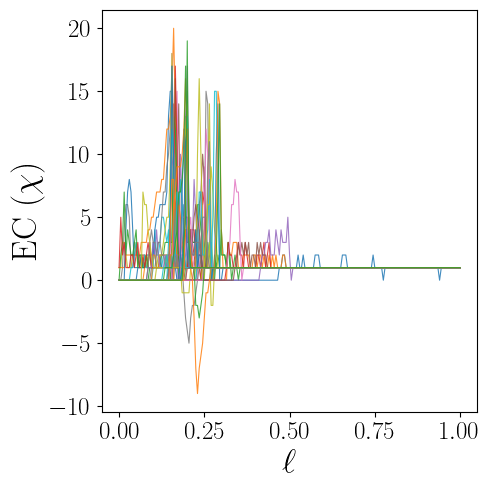

In [7]:
# Plot EC curves for all windows

plt.figure(figsize=(5, 5))

for k in range(nwindows):
    plt.plot(filtrations, window_ec[k], lw=0.8, alpha=0.85)

plt.ylabel(r"EC $(\chi)$", fontsize=25)
plt.xlabel(r"$\ell$", fontsize=25)
plt.tight_layout()
plt.show()

## Normalize EC Curves

The EC curves are normalized by the maximum absolute EC magnitude across all windows:

$$
\widetilde{\chi}_k(\ell)
=
\frac{\chi_k(\ell)}
{\max_{k,\ell}|\chi_k(\ell)|}
$$

This keeps the descriptor scale consistent before learning the temporal evolution of the EC curves.

In [8]:
# Normalize EC curves

vmax = np.max(np.abs(window_ec)) + 1e-12
EC = (window_ec / vmax).astype(np.float32)

T_ec, F = EC.shape

## Prepare EC-Derivative Learning Problem

The trajectory-based TDA workflow analyzes how EC curves evolve across moving windows.

The finite-difference derivative is approximated as:

$$
\frac{d\chi(\tau_k)}{d\tau}
\approx
\frac{\chi_{k+1} - \chi_k}{\Delta \tau}
$$

where $\Delta \tau$ is the time spacing between representative window times.

The learning problem is formulated as:

$$
\chi_k \mapsto \frac{d\chi(\tau_k)}{dt\tau}
$$

For this synthetic example, we use a dense neural network for vector-to-vector regression. In smoother high-dimensional datasets, this step can be replaced by a NODE model to learn continuous-time descriptor dynamics.

In [9]:
# Prepare derivative targets

dtau = np.mean(np.diff(tau))

dEC_dt = (EC[1:] - EC[:-1]) / dtau
X_desc = EC[:-1]

# Standardize inputs and outputs using all descriptor data.
mu_x = X_desc.mean(axis=0)
sig_x = X_desc.std(axis=0) + 1e-8
Xn = (X_desc - mu_x) / sig_x

mu_y = dEC_dt.mean(axis=0)
sig_y = dEC_dt.std(axis=0) + 1e-8
Yn = (dEC_dt - mu_y) / sig_y

n = Xn.shape[0]
n_train = int(0.8 * n)

Xtr, Xva = Xn[:n_train], Xn[n_train:]
Ytr, Yva = Yn[:n_train], Yn[n_train:]

## Train Dense NN for EC-Derivative Prediction

The model maps normalized EC curves to their estimated temporal derivatives:

$$
f_{\theta}: \mathbb{R}^{r} \rightarrow \mathbb{R}^{r}
$$

where $r$ is the number of filtration thresholds.

The model output is interpreted as a learned estimate of the topological descriptor velocity:

$$
\dot{\chi}_k = f_{\theta}(\chi_k)
$$

A dense NN is used here because the synthetic TTS dataset has only three variables, which can lead to highly piecewise-constant EC curves. In higher-dimensional process datasets with smoother EC trajectories, a NODE model is more appropriate for learning continuous-time descriptor dynamics.

In [10]:
# Train dense NN: EC(t) -> dEC/dt(t)

np.random.seed(123)
tf.random.set_seed(123)

model = models.Sequential([
    layers.Input(shape=(F,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(F, activation=None)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss=tf.keras.losses.Huber(delta=1.0)
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

rlr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-6
)

print("Training NN: EC(t) -> dEC/dt(t) ...")

history = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=400,
    batch_size=64,
    callbacks=[es, rlr],
    verbose=1,
    shuffle=False
)

Training NN: EC(t) -> dEC/dt(t) ...
Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step - loss: 0.2484 - val_loss: 0.1527 - learning_rate: 5.0000e-04
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.2407 - val_loss: 0.1470 - learning_rate: 5.0000e-04
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2336 - val_loss: 0.1417 - learning_rate: 5.0000e-04
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.2270 - val_loss: 0.1368 - learning_rate: 5.0000e-04
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2209 - val_loss: 0.1322 - learning_rate: 5.0000e-04
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2153 - val_loss: 0.1280 - learning_rate: 5.0000e-04
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2101 - val_loss: 0.1240 - learning_rate: 5.0000e-04
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2053 - val_loss: 0.1203 - learning_rate: 5.0000e-04
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.2010 - 

## Compute TDA-Based Monitoring Signal

The trained model predicts the EC-curve derivative for each moving window:

$$
\dot{\chi}_k
=
f_{\theta}(\chi_k)
$$

The event-detection signal is the norm of the predicted topological velocity:

$$
\left\|
\dot{\chi}_k
\right\|
$$

Large values indicate abrupt changes in the learned topological trajectory and are therefore interpreted as event signatures.

In [11]:
# Predict EC derivatives and compute norm

dEC_dt_hat_n = model.predict(Xn, batch_size=256, verbose=0)
dEC_dt_hat = dEC_dt_hat_n * sig_y + mu_y

# Pad the last row so the signal has one value per window.
dEC_dt_hat_full = np.vstack([dEC_dt_hat, dEC_dt_hat[-1:]])

norm_dEC_dt = np.linalg.norm(dEC_dt_hat_full, axis=1)

## Optional Smoothing

A light exponential moving average (EMA) is used to smooth the TDA monitoring signal for visualization:

$$
\bar{s}_k
=
\alpha s_k
+
(1-\alpha)\bar{s}_{k-1}
$$

In [12]:
# Optional smoothing

def ema(x, alpha=0.60):
    y = np.empty_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1.0 - alpha) * y[i - 1]
    return y

norm_dEC_dt_plot = ema(norm_dEC_dt, alpha=0.60)

## Plot TDA-Based Event Detection Results

The TDA monitoring signal is plotted against the representative time $\tau_k$, which maps the window-scale result back to the original physical time axis of the process.

For this synthetic TTS dataset, the monitoring horizon is approximately 4000 minutes.

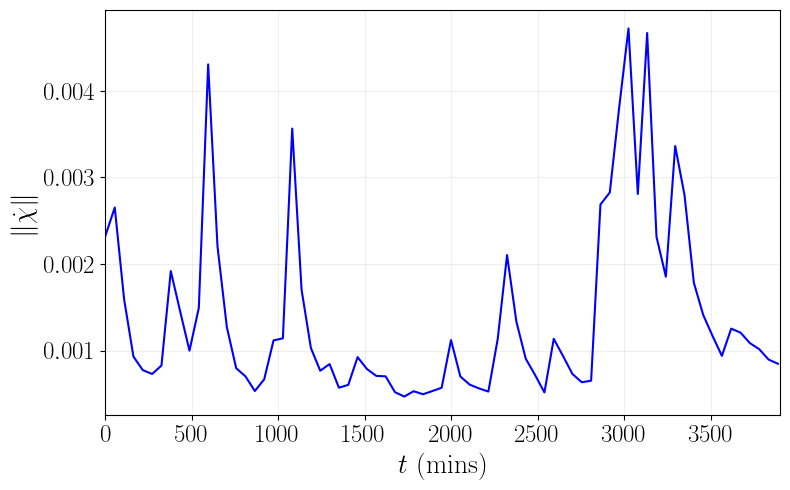

In [13]:
# Plot TDA monitoring signal

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    tau,
    norm_dEC_dt_plot,
    color="blue",
    lw=1.5
)

ax.set_xlabel(r"$t$ (mins)")
ax.set_ylabel(r"$\|\dot\chi\|$")
ax.set_xlim(0, 3900)
ax.grid(True, alpha=0.20)

plt.tight_layout()
plt.show()